In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/amazon-sales-dataset/amazon_sales_dataset.csv


In [2]:
import pandas as pd

df = pd.read_csv("/kaggle/input/amazon-sales-dataset/amazon_sales_dataset.csv")

df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.0+ MB


In [4]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [5]:
df.dtypes

order_id                     int64
order_date          datetime64[ns]
product_id                   int64
product_category            object
price                      float64
discount_percent             int64
quantity_sold                int64
customer_region             object
payment_method              object
rating                     float64
review_count                 int64
discounted_price           float64
total_revenue              float64
dtype: object

In [6]:
df.isnull().sum()

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [9]:
df["month"] = df["order_date"].dt.to_period("M")
df["year"] = df["order_date"].dt.year

In [10]:
regional_kpis = df.groupby("customer_region").agg({
    "order_id": "nunique",
    "quantity_sold": "sum",
    "total_revenue": "sum",
    "discount_percent": "mean",
    "rating": "mean"
}).reset_index()

regional_kpis.columns = [
    "Region",
    "Total_Orders",
    "Total_Quantity",
    "Total_Revenue",
    "Avg_Discount",
    "Avg_Rating"
]

regional_kpis.sort_values("Total_Revenue", ascending=False)

,Region,Total_Orders,Total_Quantity,Total_Revenue,Avg_Discount,Avg_Rating
2,Middle East,12505,37694,8301844.50,13.228309,3.015434
3,North America,12517,37534,8277217.84,13.299912,3.000360
0,Asia,12526,37440,8175199.83,13.483155,2.995721
1,Europe,12452,37302,8112311.57,13.351269,2.973651


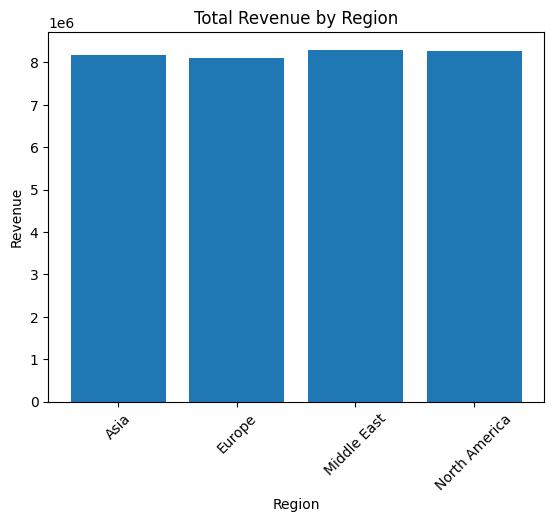

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(regional_kpis["Region"], regional_kpis["Total_Revenue"])
plt.title("Total Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [12]:
monthly_sales = df.groupby(["month", "customer_region"])["total_revenue"].sum().reset_index()
monthly_sales["month"] = monthly_sales["month"].astype(str)

monthly_sales.head()

,month,customer_region,total_revenue
0,2022-01,Asia,355294.67
1,2022-01,Europe,365360.20
2,2022-01,Middle East,349003.96
3,2022-01,North America,350093.06
4,2022-02,Asia,293376.67


In [13]:
pivot_table = monthly_sales.pivot(
    index="customer_region",
    columns="month",
    values="total_revenue"
)

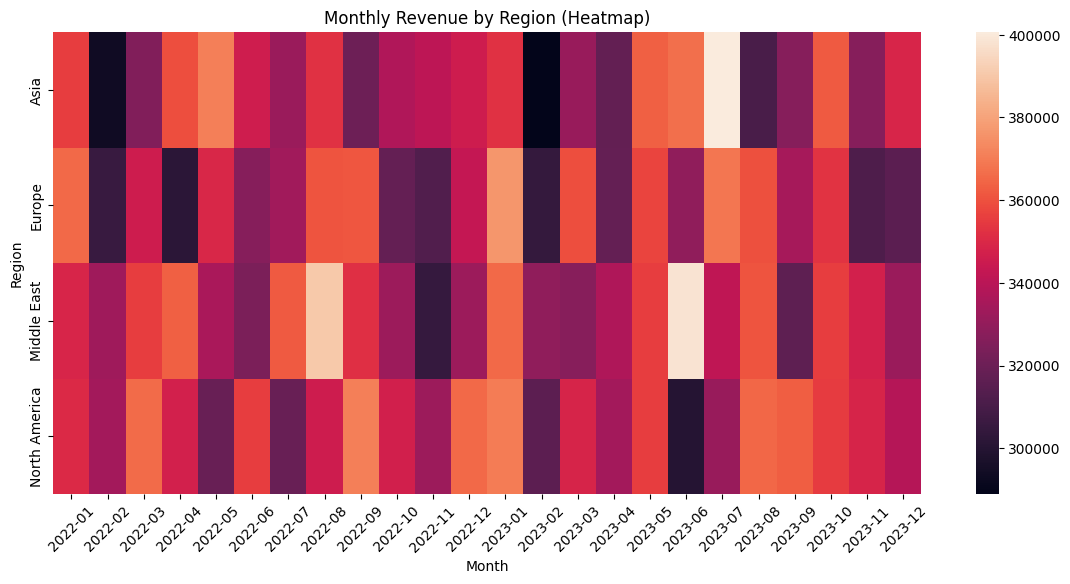

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))
sns.heatmap(pivot_table, annot=False)

plt.title("Monthly Revenue by Region (Heatmap)")
plt.xlabel("Month")
plt.ylabel("Region")
plt.xticks(rotation=45)
plt.show()